In [176]:
# %pip install graphviz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve,roc_auc_score
from sklearn.linear_model import ElasticNet,Lasso,Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from scipy import stats
from sklearn.feature_selection import f_regression
from sklearn.datasets import load_breast_cancer
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from sklearn.dummy import DummyClassifier
import graphviz
import math
warnings.filterwarnings('ignore')
df = pd.read_csv('../../Datasets/fromclass/house.csv')

In [177]:

X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



no_feature_cols = ['BsmtQual','Alley', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                   'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                   'PoolQC', 'Fence', 'MiscFeature']

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
catagorical_cols = X_train.select_dtypes(include=['object']).columns

for col in no_feature_cols:
  X_train[col] = X_train[col].fillna('None')
  X_test[col] = X_test[col].fillna('None')



for col in catagorical_cols:
  if col not in no_feature_cols and X_train[col].isnull().sum () > 0:
    most_frequent = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(most_frequent)
    X_test[col] = X_test[col].fillna(most_frequent)
    



zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea', 'GarageCars']

for col in zero_cols:
      X_train[col] = X_train[col].fillna(0)
      X_test[col] = X_test[col].fillna(0)

X_train['LotFrontage'] = X_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x:x.fillna(x.median()))
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(X_train['LotFrontage'].median())
X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(X_train['GarageYrBlt'].median())

X_test['LotFrontage'] = X_test.groupby('Neighborhood')['LotFrontage'].transform(lambda x:x.fillna(x.median()))
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(X_test['LotFrontage'].median())
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(X_test['GarageYrBlt'].median())


quality_mapping = {'None': 0, 'Po': 1,'Fa': 2,'TA': 3,'Gd': 4,'Ex': 5}
basement_exposure_mapping = {'None': 0,'No': 1,'Mn': 2,'Av': 3,'Gd': 4}
basement_finish_mapping = {'None': 0,'Unf': 1,'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5,'GLQ': 6}
fence_mapping = {'None': 0,'MnWw': 1,'GdWo': 2,'MnPrv': 3,'GdPrv': 4}
garage_finish_mapping = {'None': 0,'Unf': 1,'RFn': 2,'Fin': 3}
lot_shape_mapping = {'Reg': 3,'IR1': 2,'IR2': 1,'IR3': 0}
functional_mapping = {'Sal': 0,'Sev': 1,'Maj2': 2,'Maj1': 3,'Mod': 4,'Min2': 5,'Min1': 6,'Typ': 7}

ordinal_features = {
    'ExterQual': quality_mapping,
    'ExterCond': quality_mapping,
    'BsmtQual': quality_mapping,
    'BsmtCond': quality_mapping,
    'BsmtExposure': basement_exposure_mapping,
    'BsmtFinType1': basement_finish_mapping,   
    'BsmtFinType2': basement_finish_mapping,
    'HeatingQC': quality_mapping,
    'KitchenQual': quality_mapping,
    'FireplaceQu': quality_mapping,
    'GarageQual': quality_mapping,
    'GarageCond': quality_mapping,
    'GarageFinish': garage_finish_mapping,
    'PoolQC': quality_mapping,
    'Fence': fence_mapping,
    'LotShape': lot_shape_mapping,
    'Functional': functional_mapping,
    'CentralAir': {'N': 0, 'Y': 1}
}
for feature, mapping in ordinal_features.items():
        X_train[feature] = X_train[feature].map(mapping)
        X_test[feature] = X_test[feature].map(mapping)


nominal_features = [
    'MSZoning','Street','Alley','LandContour','LotConfig','Neighborhood',
    'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl',
    'Exterior1st','Exterior2nd','MasVnrType','Foundation','Heating','Electrical',
    'GarageType','MiscFeature','SaleType','SaleCondition','Utilities','LandSlope','PavedDrive'
]
nominal_features = [f for f in nominal_features if f in X_train.columns]

X_all = pd.concat([X_train, X_test], axis=0)
X_all = pd.get_dummies(X_all, columns=nominal_features, drop_first=True)

X_train = X_all.iloc[:len(X_train)]
X_test  = X_all.iloc[len(X_train):]

sclaer = StandardScaler()

# X_train[numerical_cols] = sclaer.fit_transform(X_train[numerical_cols])
# X_test[numerical_cols] = sclaer.fit_transform(X_test[numerical_cols])

train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

misssing_values = X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False)
misssing_valuesp = (misssing_values / len(X_train)) *100
cols_to_drop = [
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',        
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',  
    'YearBuilt', 'YearRemodAdd',              
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',  
    'PoolArea',                                   

]

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test  = X_test.drop(columns=cols_to_drop, errors='ignore')


X_train = X_train.astype({col: "int" for col in X_train.select_dtypes("bool").columns})
X_train = X_train.replace({True: 1, False: 0})

X_test = X_test.astype({col: "int" for col in X_test.select_dtypes("bool").columns})
X_test = X_test.replace({True: 1, False: 0})




X_train.shape
model = LinearRegression()


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

r2 = r2_score(y_pred, y_test)

print(f'R2 Score: {r2}')


y_train


R2 Score: 0.7419443473441449


135     174000
1452    145000
762     215200
932     320000
435     212000
         ...  
1095    176432
1130    135000
1294    115000
860     189950
1126    174000
Name: SalePrice, Length: 1022, dtype: int64

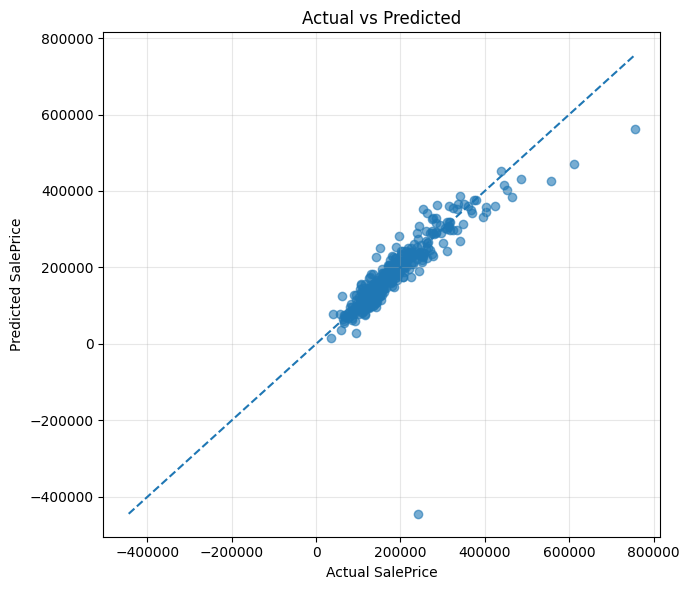

In [178]:


# y_test and y_pred must be 1D arrays/Series
y_test_arr = np.array(y_test).ravel()
y_pred_arr = np.array(y_pred).ravel()

plt.figure(figsize=(7,6))
plt.scatter(y_test_arr, y_pred_arr, alpha=0.6)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

# perfect line
mn = min(y_test_arr.min(), y_pred_arr.min())
mx = max(y_test_arr.max(), y_pred_arr.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [179]:
# residuals = y_test_arr - y_pred_arr

# plt.figure(figsize=(7,4))
# plt.scatter(y_pred_arr, residuals, alpha=0.6)
# plt.axhline(0, linestyle="--")
# plt.xlabel("Predicted SalePrice")
# plt.ylabel("Residual (Actual - Predicted)")
# plt.title("Residuals vs Predicted")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()